# Paper 1 — Revision Experiments

This notebook produces the new experiments requested in review, on the multi-writer Persian
handwritten digit dataset. It is self-contained and reuses the same CNN and classical pipeline
as the original study.

| Reviewer point | Section here |
|---|---|
| Dataset characterisation (10 writers, 100% labelled, class distribution) | 1 |
| Class-imbalance explanation (digits 2 and 3, from the 7 primary writers) | 1 |
| **Writer-independent evaluation** (10-writer leave-one-writer-out vs. standard split) | 2 |
| Image-resolution justification (why 16×16) | 3 |
| Cross-dataset generalisation — systematic factor analysis | 4 |

Run top to bottom. All tables/figures are written to `revision_results/`.

## 0. Setup

In [1]:
import os, json, math, random, warnings
from pathlib import Path
from collections import Counter, OrderedDict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":110,"savefig.bbox":"tight"})
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu"); print("device",DEVICE)

device cuda


In [2]:
BASE = Path(r"C:\Users\c8472912\Desktop\D\paper\digits\final\paper")
CONFIG = {
    "DATA_DIR": str(BASE / "dataset"),
    "HODA_DIR": str(BASE / "Hoda"),
    "RESULTS_DIR": str(BASE / "revision_results"),
    "N_CLASSES": 10,
    "SEEDS": [0, 1],           # raise for tighter error bars
    "EPOCHS": 60, "EARLY_STOP_PATIENCE": 8, "BATCH_SIZE": 64,
    "LR": 1e-3, "WEIGHT_DECAY": 1e-4, "DROPOUT": 0.3,
    "AUG_MAX_SHIFT": 2,
}
os.makedirs(CONFIG["RESULTS_DIR"], exist_ok=True)
DIGITS=list(range(10))
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
set_seed(0)

## 1. Dataset characterisation

Loads the dataset from the per-digit folders and recovers the writer of every image from its
filename. Ten writers contributed the 2,560 images; **writer identity is available for 100% of
the images**. Seven writers contributed the full range of digits; three (morteza, aysan, ali)
contributed smaller balanced sets. The over-representation of digits 2 and 3 comes from the seven
primary writers, who each supplied extra 2s and 3s after that confusion was observed.

In [3]:
import re
from PIL import Image
# recover the writer of each image from its filename (7 name-prefixed + 3 numbering schemes)
NAMES = {"aila":"aila","alireza":"alireza","reyhane":"reyhane","dj":"dorna",
         "ma":"maha","sa":"hanye","n":"negin"}
def writer_of(fname):
    b = re.sub(r'\.(jpg|jpeg|png)$','',fname,flags=re.I); low = b.lower()
    for p in ["aila","alireza","reyhane","dj","ma","sa","n"]:
        if low.startswith(p) and (len(low)==len(p) or not low[len(p)].isalpha()):
            return NAMES[p]
    if low.startswith("m") and (len(low)==1 or not low[1].isalpha()): return "morteza"  # m- (not ma)
    if re.match(r'^\d+\.\d+$', b):      return "aysan"     # dotted   0.1 ...
    if re.match(r'^0\d$', b):           return "ali"       # zero-pad 01 .. 09
    if re.match(r'^\d+( \(\d\))?$', b): return "morteza"   # plain    1 .. 20
    return None                                            # stray file -> skip

def load_folders(data_dir, image_size=16):
    X,y,w = [],[],[]
    for c in range(10):
        cd = Path(data_dir)/str(c)
        if not cd.exists(): continue
        for fp in sorted(cd.iterdir()):
            if fp.suffix.lower() not in (".jpg",".jpeg",".png"): continue
            wr = writer_of(fp.name)
            if wr is None: continue
            img = Image.open(fp).convert("L").resize((image_size,image_size))
            X.append(np.asarray(img,dtype=np.float32)); y.append(c); w.append(wr)
    return np.stack(X)[:,None]/255.0, np.asarray(y,dtype=np.int64), np.asarray(w,dtype=object)

X_all, y_all, w_all = load_folders(CONFIG["DATA_DIR"], 16)
IMAGE_SIZE = X_all.shape[-1]; N = len(y_all)
known = np.ones(N, dtype=bool)                              # every image has a writer now
print(f"images: {N}, native size: {IMAGE_SIZE}x{IMAGE_SIZE}, writers: {len(set(w_all))} (100% labelled)")
print("per-class counts:", {int(k):int(v) for k,v in zip(*np.unique(y_all, return_counts=True))})
named = sorted(set(w_all.tolist()), key=lambda wr:-int((w_all==wr).sum()))
print("images per writer:", {wr:int((w_all==wr).sum()) for wr in named})

mat = pd.DataFrame(0, index=named, columns=DIGITS)
for wr in named:
    for c in DIGITS: mat.loc[wr,c] = int(((w_all==wr)&(y_all==c)).sum())
mat["total"] = mat.sum(axis=1)
mat.to_csv(Path(CONFIG["RESULTS_DIR"])/"writer_class_matrix.csv")
print("\nwriter x class:\n", mat)

images: 2559, native size: 16x16, writers: 10 (100% labelled)
per-class counts: {0: 187, 1: 196, 2: 533, 3: 533, 4: 192, 5: 186, 6: 187, 7: 182, 8: 182, 9: 181}
images per writer: {'aila': 319, 'maha': 314, 'dorna': 310, 'reyhane': 300, 'negin': 300, 'hanye': 300, 'alireza': 300, 'morteza': 226, 'aysan': 100, 'ali': 90}

writer x class:
           0   1   2   3   4   5   6   7   8   9  total
aila     20  21  70  70  30  23  24  21  20  20    319
maha     10  34  72  72  21  22  22  20  21  20    314
dorna    21  21  71  71  21  21  21  21  21  21    310
reyhane  20  20  70  70  20  20  20  20  20  20    300
negin    20  20  70  70  20  20  20  20  20  20    300
hanye    20  20  70  70  20  20  20  20  20  20    300
alireza  20  20  70  70  20  20  20  20  20  20    300
morteza  37  21  21  21  21  21  21  21  21  21    226
aysan    10  10  10  10  10  10  10  10  10  10    100
ali       9   9   9   9   9   9   9   9   9   9     90


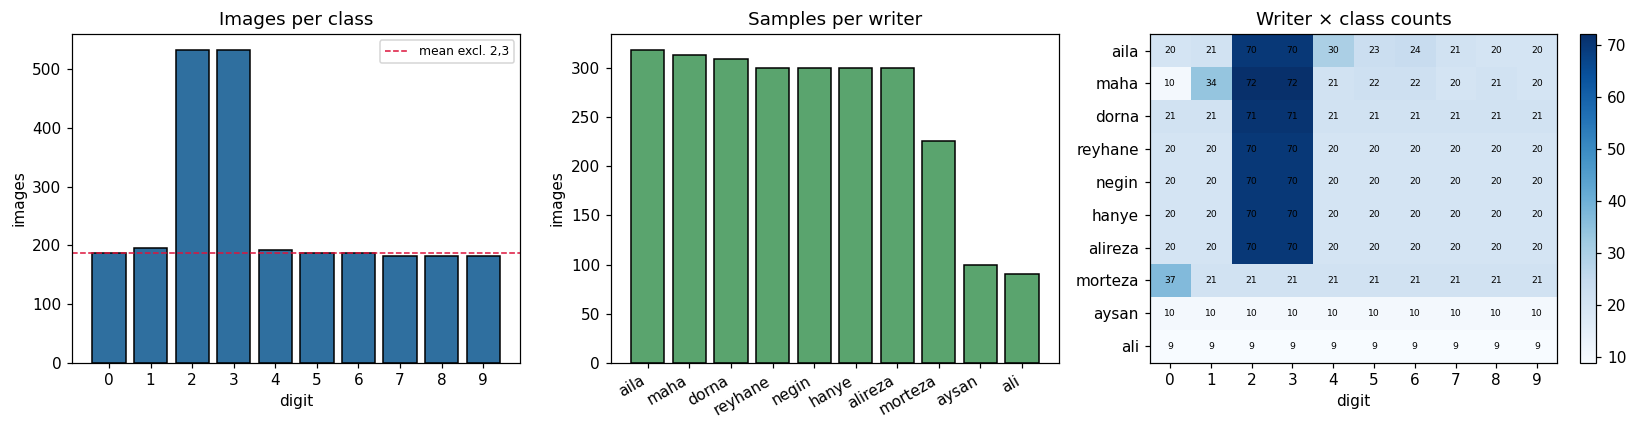

In [4]:
# figures: per-class counts, samples per writer, writer x class heatmap
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cnts=[int((y_all==c).sum()) for c in DIGITS]
ax[0].bar(DIGITS, cnts, color="#2f6f9f", edgecolor="black")
ax[0].set_xticks(DIGITS); ax[0].set_xlabel("digit"); ax[0].set_ylabel("images"); ax[0].set_title("Images per class")
ax[0].axhline(np.mean([cnts[c] for c in DIGITS if c not in (2,3)]), color="crimson", ls="--", lw=1, label="mean excl. 2,3")
ax[0].legend(fontsize=8)
sw={wr:int((w_all==wr).sum()) for wr in named}
ax[1].bar(range(len(sw)), list(sw.values()), color="#5aa46e", edgecolor="black")
ax[1].set_xticks(range(len(sw))); ax[1].set_xticklabels(list(sw.keys()), rotation=30, ha="right")
ax[1].set_ylabel("images"); ax[1].set_title("Samples per writer")
im=ax[2].imshow(mat.loc[named, DIGITS].to_numpy(), cmap="Blues", aspect="auto")
ax[2].set_xticks(DIGITS); ax[2].set_yticks(range(len(named))); ax[2].set_yticklabels(named)
ax[2].set_xlabel("digit"); ax[2].set_title("Writer × class counts")
for i in range(len(named)):
    for c in DIGITS:
        ax[2].text(c,i,int(mat.loc[named[i],c]),ha="center",va="center",fontsize=6)
fig.colorbar(im, ax=ax[2], fraction=0.04)
plt.tight_layout(); plt.savefig(Path(CONFIG["RESULTS_DIR"])/"fig_dataset_characterisation.png", dpi=200); plt.show()

## Models and training helpers

Same architecture and protocol as the original paper: a small CNN (1→32→64, 3×3, BN, ReLU,
max-pool) and classical models behind StandardScaler→PCA(0.95). Normalisation/PCA are fit on the
training partition of each fold only (no leakage); light pixel-shift augmentation is applied to
training images only.

In [5]:
class DigitCNN(nn.Module):
    def __init__(self, image_size=16, n_classes=10, dropout=0.3):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(1,32,3,1,1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,1,1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2))
        with torch.no_grad():
            flat=self.features(torch.zeros(1,1,image_size,image_size)).numel()
        self.classifier=nn.Sequential(nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(flat,128), nn.ReLU(True), nn.Dropout(dropout), nn.Linear(128,n_classes))
    def forward(self,x): return self.classifier(self.features(x))

class DS(Dataset):
    def __init__(self,X,y,mean,std,aug=False,ms=2):
        self.X,self.y,self.mean,self.std,self.aug,self.ms=X,y,mean,std,aug,ms
    def __len__(self): return len(self.y)
    def _shift(self,img):
        dx=np.random.randint(-self.ms,self.ms+1); dy=np.random.randint(-self.ms,self.ms+1)
        img=np.roll(img,(dy,dx),axis=(1,2))
        if dy>0: img[:,:dy,:]=0
        elif dy<0: img[:,dy:,:]=0
        if dx>0: img[:,:,:dx]=0
        elif dx<0: img[:,:,dx:]=0
        return img
    def __getitem__(self,i):
        img=self.X[i].copy()
        if self.aug: img=self._shift(img)
        return torch.from_numpy((img-self.mean)/self.std).float(), int(self.y[i])

def train_cnn(Xtr,ytr,Xva,yva,cfg,seed,image_size):
    set_seed(seed); mean,std=float(Xtr.mean()),float(Xtr.std()+1e-7)
    tl=DataLoader(DS(Xtr,ytr,mean,std,True,cfg["AUG_MAX_SHIFT"]),batch_size=cfg["BATCH_SIZE"],shuffle=True)
    vl=DataLoader(DS(Xva,yva,mean,std),batch_size=256)
    m=DigitCNN(image_size,cfg["N_CLASSES"],cfg["DROPOUT"]).to(DEVICE)
    opt=torch.optim.Adam(m.parameters(),lr=cfg["LR"],weight_decay=cfg["WEIGHT_DECAY"]); crit=nn.CrossEntropyLoss()
    best,bs,wait=1e9,None,0
    for ep in range(cfg["EPOCHS"]):
        m.train()
        for xb,yb in tl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad(); crit(m(xb),yb).backward(); opt.step()
        m.eval(); vloss=0.0
        with torch.no_grad():
            for xb,yb in vl: vloss+=crit(m(xb.to(DEVICE)),yb.to(DEVICE)).item()*len(xb)
        vloss/=len(yva)
        if vloss<best-1e-4: best,bs,wait=vloss,{k:v.cpu().clone() for k,v in m.state_dict().items()},0
        else:
            wait+=1
            if wait>=cfg["EARLY_STOP_PATIENCE"]: break
    m.load_state_dict(bs); return m,(mean,std)

@torch.no_grad()
def predict_cnn(m,X,y,st):
    dl=DataLoader(DS(X,y,st[0],st[1]),batch_size=256); m.eval(); out=[]
    for xb,_ in dl: out.append(m(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(out)

def make_classifiers():
    return OrderedDict([
        ("KNN",KNeighborsClassifier(n_neighbors=3)),
        ("SVM",SVC(kernel="poly",degree=2,gamma=0.01,C=10)),
        ("Naive Bayes",GaussianNB()),
        ("Decision Tree",DecisionTreeClassifier(max_depth=11,min_samples_leaf=3,min_samples_split=7,random_state=0)),
        ("Random Forest",RandomForestClassifier(n_estimators=300,random_state=0))])
def make_pipe(clf): return Pipeline([("s",StandardScaler()),("p",PCA(0.95,random_state=0)),("c",clf)])
MODELS=["CNN"]+list(make_classifiers().keys())

def fit_predict_all(Xtr,ytr,Xte,yte,cfg,seed,image_size):
    preds={}
    # internal validation split (from the training partition only) for CNN early stopping
    itr,iva=train_test_split(np.arange(len(ytr)),test_size=max(0.15,cfg['N_CLASSES']/len(ytr)),stratify=ytr,random_state=seed)
    m,st=train_cnn(Xtr[itr],ytr[itr],Xtr[iva],ytr[iva],cfg,seed,image_size)
    preds["CNN"]=predict_cnn(m,Xte,yte,st)
    Xtrf,Xtef=Xtr.reshape(len(Xtr),-1),Xte.reshape(len(Xte),-1)
    for name,clf in make_classifiers().items():
        preds[name]=make_pipe(clf).fit(Xtrf,ytr).predict(Xtef)
    return preds

## 2. Writer-dependent vs. writer-independent evaluation

The key new experiment. We restrict to the writers who contributed all ten digits and compare two
protocols on the **same image pool**, differing only in how folds are formed:

- **Writer-dependent (WD):** stratified k-fold — samples from a writer may appear in both train and test.
- **Writer-independent (WI):** leave-one-writer-out — the test writer is never seen in training.

The gap WD − WI measures how much accuracy depends on having seen the test writer.

In [6]:
main_writers=[wr for wr in named if int((w_all==wr).sum())>=50]   # all writers with a usable set
mask=np.isin(w_all, main_writers)
Xw,yw,gw=X_all[mask],y_all[mask],w_all[mask]
print("writer-independent pool:",len(yw),"images from",len(main_writers),"writers:",main_writers)

def macro(yt,yp): return accuracy_score(yt,yp), precision_recall_fscore_support(yt,yp,average="macro",zero_division=0)[2]

# WD: stratified k-fold (k = number of writers, for comparability), repeated over seeds
rows=[]
K=len(main_writers)
wd_acc={m:[] for m in MODELS}
for seed in CONFIG["SEEDS"]:
    skf=StratifiedKFold(K,shuffle=True,random_state=seed)
    for tr,te in skf.split(Xw,yw):
        pr=fit_predict_all(Xw[tr],yw[tr],Xw[te],yw[te],CONFIG,seed,IMAGE_SIZE)
        for m in MODELS: wd_acc[m].append(macro(yw[te],pr[m])[0])
# WI: leave-one-writer-out
wi_acc={m:[] for m in MODELS}
logo=LeaveOneGroupOut()
for tr,te in logo.split(Xw,yw,gw):
    pr=fit_predict_all(Xw[tr],yw[tr],Xw[te],yw[te],CONFIG,CONFIG["SEEDS"][0],IMAGE_SIZE)
    for m in MODELS: wi_acc[m].append(macro(yw[te],pr[m])[0])

tbl=[]
for m in MODELS:
    wd,wi=np.array(wd_acc[m]),np.array(wi_acc[m])
    tbl.append({"model":m,"WD_acc":wd.mean()*100,"WD_std":wd.std()*100,
                "WI_acc":wi.mean()*100,"WI_std":wi.std()*100,"gap":(wd.mean()-wi.mean())*100})
wdwi=pd.DataFrame(tbl); wdwi.to_csv(Path(CONFIG["RESULTS_DIR"])/"writer_dependent_vs_independent.csv",index=False)
print(wdwi.round(2).to_string(index=False))

writer-independent pool: 2559 images from 10 writers: ['aila', 'maha', 'dorna', 'reyhane', 'negin', 'hanye', 'alireza', 'morteza', 'aysan', 'ali']


  File "C:\Users\c8472912\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\c8472912\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\c8472912\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\c8472912\AppData\Local\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


        model  WD_acc  WD_std  WI_acc  WI_std  gap
          CNN   97.01    1.01   96.11    1.98 0.90
          KNN   80.01    2.19   77.13    4.50 2.88
          SVM   86.19    1.64   81.02   14.85 5.16
  Naive Bayes   37.12    2.89   33.86    8.72 3.27
Decision Tree   57.72    3.15   53.13    7.07 4.58
Random Forest   78.06    2.47   72.37    7.15 5.69


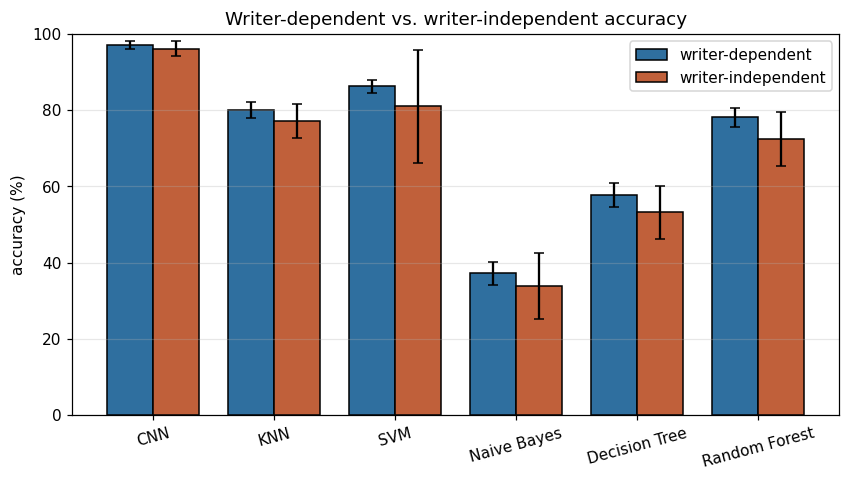

In [7]:
fig,ax=plt.subplots(figsize=(9,4.5)); x=np.arange(len(MODELS)); wbar=0.38
ax.bar(x-wbar/2,[wdwi.set_index('model').loc[m,'WD_acc'] for m in MODELS],wbar,
       yerr=[wdwi.set_index('model').loc[m,'WD_std'] for m in MODELS],capsize=3,label="writer-dependent",color="#2f6f9f",edgecolor="black")
ax.bar(x+wbar/2,[wdwi.set_index('model').loc[m,'WI_acc'] for m in MODELS],wbar,
       yerr=[wdwi.set_index('model').loc[m,'WI_std'] for m in MODELS],capsize=3,label="writer-independent",color="#c0603a",edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(MODELS,rotation=15); ax.set_ylabel("accuracy (%)"); ax.set_ylim(0,100)
ax.set_title("Writer-dependent vs. writer-independent accuracy"); ax.legend(); ax.grid(axis="y",alpha=.3)
plt.savefig(Path(CONFIG["RESULTS_DIR"])/"fig_writer_independent.png",dpi=200); plt.show()

## 3. Resolution ablation

The images are stored natively at 16×16. We cannot recover detail that was never captured, but we
can test whether the **pixel grid** is the limiting factor by upsampling to larger sizes and
re-training. If accuracy and the 2↔3 confusion do not improve, resolution is not the bottleneck.

resolution  cnn_acc  cnn_std  confusion_2_3
     16x16    95.41     0.10           3.50
     20x20    95.51     0.20           1.64
     24x24    95.70     0.00           3.27
     28x28    95.90     0.39           2.80


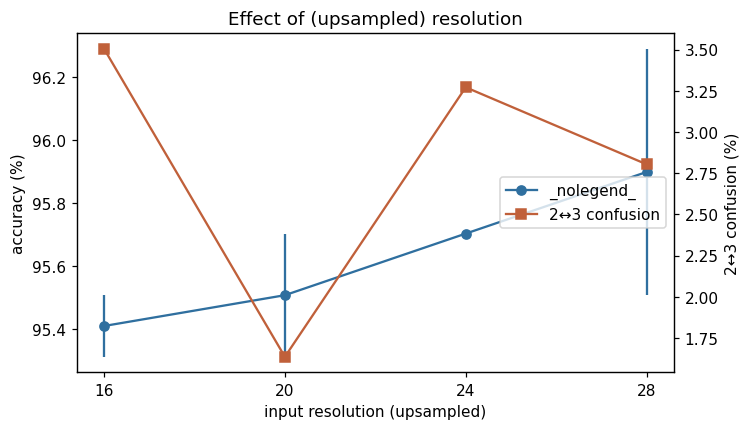

In [8]:
from PIL import Image
def resize_stack(X, size):
    out=np.zeros((len(X),1,size,size),dtype=np.float32)
    for i in range(len(X)):
        out[i,0]=np.asarray(Image.fromarray((X[i,0]*255).astype(np.uint8)).resize((size,size),Image.BILINEAR),dtype=np.float32)/255.0
    return out

res_rows=[]
dev,test=train_test_split(np.arange(N),test_size=0.2,stratify=y_all,random_state=0)
for size in [16,20,24,28]:
    Xr=X_all if size==16 else resize_stack(X_all,size)
    accs=[]; conf23=[]
    for seed in CONFIG["SEEDS"]:
        pr=fit_predict_all(Xr[dev],y_all[dev],Xr[test],y_all[test],CONFIG,seed,size)["CNN"]
        accs.append(accuracy_score(y_all[test],pr))
        cm=confusion_matrix(y_all[test],pr,labels=DIGITS).astype(float)
        cmn=cm/cm.sum(1,keepdims=True).clip(min=1)
        conf23.append((cmn[2,3]+cmn[3,2])/2)
    res_rows.append({"resolution":f"{size}x{size}","cnn_acc":np.mean(accs)*100,"cnn_std":np.std(accs)*100,
                     "confusion_2_3":np.mean(conf23)*100})
resdf=pd.DataFrame(res_rows); resdf.to_csv(Path(CONFIG["RESULTS_DIR"])/"resolution_ablation.csv",index=False)
print(resdf.round(2).to_string(index=False))
fig,ax=plt.subplots(figsize=(7,4)); xs=[16,20,24,28]
ax.errorbar(xs,resdf["cnn_acc"],yerr=resdf["cnn_std"],marker="o",label="CNN accuracy",color="#2f6f9f")
ax2=ax.twinx(); ax2.plot(xs,resdf["confusion_2_3"],marker="s",color="#c0603a",label="2↔3 confusion")
ax.set_xlabel("input resolution (upsampled)"); ax.set_ylabel("accuracy (%)"); ax2.set_ylabel("2↔3 confusion (%)")
ax.set_title("Effect of (upsampled) resolution"); ax.set_xticks(xs)
lines=ax.get_lines()+ax2.get_lines(); ax.legend(lines,[l.get_label() for l in lines],loc="center right")
plt.savefig(Path(CONFIG["RESULTS_DIR"])/"fig_resolution.png",dpi=200); plt.show()

## 4. Cross-dataset generalisation — systematic factor analysis

The cross-dataset gap could be caused by resolution, preprocessing, class distribution, or genuine
writing-style differences. We start from a raw comparison and add controls one at a time, measuring
how much of the gap each removes. Whatever gap survives all controls is the residual style difference.

                    stage  ours→HODA  HODA→ours  asymmetry
                      raw      31.23       8.36      22.87
+ canonical preprocessing      96.05      83.78      12.27
          + class balance      93.13      85.67       7.47


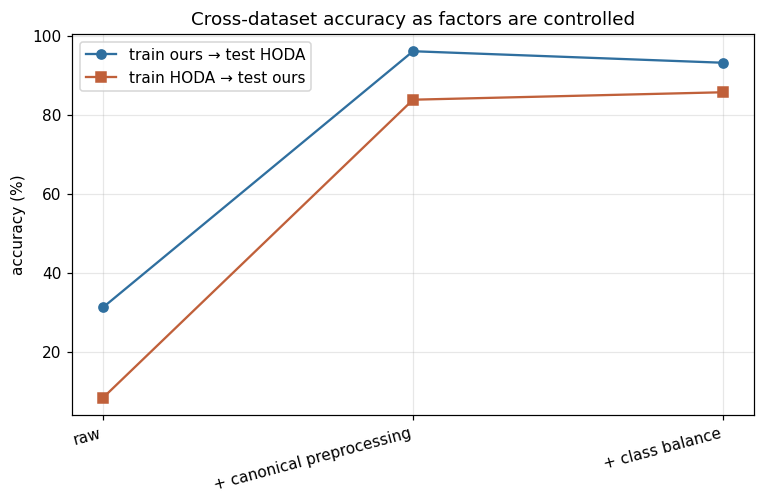

In [9]:
def load_hoda(hoda_dir, image_size):
    import sys
    sys.path.insert(0,str(hoda_dir))
    if not hasattr(np,"int"): np.int=int
    from HodaDatasetReader import read_hoda_dataset
    def _l(cdb):
        Xr,Yr=read_hoda_dataset(os.path.join(hoda_dir,"DigitDB",cdb),images_height=image_size,images_width=image_size,one_hot=False,reshape=False)
        return Xr.transpose(0,3,1,2).astype(np.float32),Yr.astype(np.int64)
    Xtr,ytr=_l("Train 60000.cdb"); return Xtr,ytr

def canonicalize(X, pad_frac=0.15):
    from PIL import Image
    Xc=X.copy().astype(np.float32); br=Xc.reshape(len(Xc),-1).mean(1)>0.5; Xc[br]=1-Xc[br]
    Xc=(Xc>=0.5).astype(np.float32); out=Xc.shape[-1]; tgt=max(1,int(round(out*(1-2*pad_frac)))); res=np.zeros_like(Xc)
    for i in range(len(Xc)):
        img=Xc[i,0]; ys,xs=np.where(img>0)
        if len(xs)==0: continue
        cr=img[ys.min():ys.max()+1,xs.min():xs.max()+1]; h,w=cr.shape; s=tgt/max(h,w)
        nh,nw=max(1,int(round(h*s))),max(1,int(round(w*s)))
        rz=(np.asarray(Image.fromarray((cr*255).astype(np.uint8)).resize((nw,nh)),dtype=np.float32)/255.0>=.5).astype(np.float32)
        oy,ox=(out-nh)//2,(out-nw)//2; res[i,0,oy:oy+nh,ox:ox+nw]=rz
    return res
def balance(X,y,n,seed=0):
    rng=np.random.RandomState(seed); idx=[]
    for c in range(10):
        ci=np.where(y==c)[0]; idx.append(rng.choice(ci,min(n,len(ci)),replace=len(ci)<n))
    idx=np.concatenate(idx); rng.shuffle(idx); return X[idx],y[idx]

try:
    Xh,yh=load_hoda(CONFIG["HODA_DIR"],IMAGE_SIZE)
    Xh,yh=balance(Xh,yh,600,0)                      # subsample HODA for speed
    Xo,yo=X_all,y_all
    def xtrain(Xtr,ytr,Xte,yte):
        itr,iva=train_test_split(np.arange(len(ytr)),test_size=0.15,stratify=ytr,random_state=0)
        m,st=train_cnn(Xtr[itr],ytr[itr],Xtr[iva],ytr[iva],CONFIG,0,IMAGE_SIZE)
        return accuracy_score(yte,predict_cnn(m,Xte,yte,st))
    stages=[]
    # stage 0: raw (same 16x16 already; different preprocessing & class balance)
    stages.append(("raw", Xo,yo,Xh,yh))
    # stage 1: + canonical preprocessing on both
    Xo_c,Xh_c=canonicalize(Xo),canonicalize(Xh)
    stages.append(("+ canonical preprocessing", Xo_c,yo,Xh_c,yh))
    # stage 2: + class balance (both balanced to 150/class)
    Xo_b,yo_b=balance(Xo_c,yo,150,1); Xh_b,yh_b=balance(Xh_c,yh,150,1)
    rows=[]
    for name,Xo_s,yo_s,Xh_s,yh_s in stages:
        o2h=xtrain(Xo_s,yo_s,Xh_s,yh_s); h2o=xtrain(Xh_s,yh_s,Xo_s,yo_s)
        rows.append({"stage":name,"ours→HODA":o2h*100,"HODA→ours":h2o*100,"asymmetry":(o2h-h2o)*100})
    o2h=xtrain(Xo_b,yo_b,Xh_b,yh_b); h2o=xtrain(Xh_b,yh_b,Xo_b,yo_b)
    rows.append({"stage":"+ class balance","ours→HODA":o2h*100,"HODA→ours":h2o*100,"asymmetry":(o2h-h2o)*100})
    cross=pd.DataFrame(rows); cross.to_csv(Path(CONFIG["RESULTS_DIR"])/"cross_dataset_factors.csv",index=False)
    print(cross.round(2).to_string(index=False))
    fig,ax=plt.subplots(figsize=(8,4.5)); xs=np.arange(len(cross))
    ax.plot(xs,cross["ours→HODA"],"-o",label="train ours → test HODA",color="#2f6f9f")
    ax.plot(xs,cross["HODA→ours"],"-s",label="train HODA → test ours",color="#c0603a")
    ax.set_xticks(xs); ax.set_xticklabels(cross["stage"],rotation=15,ha="right")
    ax.set_ylabel("accuracy (%)"); ax.set_title("Cross-dataset accuracy as factors are controlled")
    ax.legend(); ax.grid(alpha=.3)
    plt.savefig(Path(CONFIG["RESULTS_DIR"])/"fig_cross_dataset_factors.png",dpi=200); plt.show()
except Exception as e:
    print("HODA cross-dataset step skipped:", e)

## 5. Does extra training data for digits 2 and 3 help?

Digits 2 and 3 were originally collected in the same quantity as the others, but the models
confused them, so extra 2s and 3s were added to test whether more training data reduces the
confusion. This experiment answers that question directly. We freeze a **balanced** test set
(equal per digit; the extra 2/3 samples are never in it) and compare two training sets on it:
**balanced** — digits 2 and 3 capped to the level of the other digits — versus **augmented** — all
available 2s and 3s. Everything else is identical, so any difference is due to the extra 2/3 data.

 training  n_2and3_each  overall_acc  F1_digit2  F1_digit3  confusion_2to3
 balanced           156        97.33      90.76      93.55            6.67
augmented           503        97.67      94.92      96.77            3.33


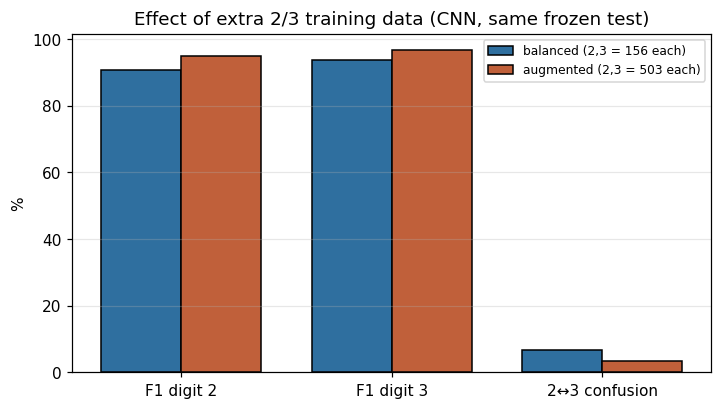

In [10]:
set_seed(0); rng=np.random.RandomState(0)
# frozen, class-balanced test set (30 per digit); extra 2/3 stay in the training pool only
per_class_test=30; test_idx=[]
for c in range(10):
    test_idx.append(rng.choice(np.where(y_all==c)[0], per_class_test, replace=False))
test_idx=np.concatenate(test_idx); tmask=np.zeros(N,bool); tmask[test_idx]=True
Xte,yte=X_all[test_idx],y_all[test_idx]; pool=np.where(~tmask)[0]
cap=int(np.median([int((y_all[pool]==c).sum()) for c in range(10) if c not in (2,3)]))  # ~ other digits
def build_train(mode):
    idx=[]
    for c in range(10):
        ci=pool[y_all[pool]==c]
        if mode=="balanced" and c in (2,3): ci=rng.permutation(ci)[:cap]
        idx.append(ci)
    idx=np.concatenate(idx); return X_all[idx],y_all[idx]

rows=[]
for mode in ["balanced","augmented"]:
    accs,f2,f3,c23=[],[],[],[]
    for seed in CONFIG["SEEDS"]:
        Xtr,ytr=build_train(mode)
        pr=fit_predict_all(Xtr,ytr,Xte,yte,CONFIG,seed,IMAGE_SIZE)["CNN"]
        accs.append(accuracy_score(yte,pr))
        _,_,f1,_=precision_recall_fscore_support(yte,pr,labels=DIGITS,zero_division=0)
        f2.append(f1[2]); f3.append(f1[3])
        cm=confusion_matrix(yte,pr,labels=DIGITS).astype(float); cmn=cm/cm.sum(1,keepdims=True).clip(min=1)
        c23.append((cmn[2,3]+cmn[3,2])/2)
    n23=cap if mode=="balanced" else int((y_all[pool]==2).sum())
    rows.append({"training":mode,"n_2and3_each":n23,"overall_acc":np.mean(accs)*100,
                 "F1_digit2":np.mean(f2)*100,"F1_digit3":np.mean(f3)*100,"confusion_2to3":np.mean(c23)*100})
imb=pd.DataFrame(rows); imb.to_csv(Path(CONFIG["RESULTS_DIR"])/"class_imbalance_ablation.csv",index=False)
print(imb.round(2).to_string(index=False))
fig,ax=plt.subplots(figsize=(7.5,4)); x=np.arange(3); wbar=0.38
b=imb[imb.training=='balanced'].iloc[0]; a=imb[imb.training=='augmented'].iloc[0]
ax.bar(x-wbar/2,[b['F1_digit2'],b['F1_digit3'],b['confusion_2to3']],wbar,label=f"balanced (2,3 = {int(b['n_2and3_each'])} each)",color="#2f6f9f",edgecolor="black")
ax.bar(x+wbar/2,[a['F1_digit2'],a['F1_digit3'],a['confusion_2to3']],wbar,label=f"augmented (2,3 = {int(a['n_2and3_each'])} each)",color="#c0603a",edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(["F1 digit 2","F1 digit 3","2↔3 confusion"]); ax.set_ylabel("%")
ax.set_title("Effect of extra 2/3 training data (CNN, same frozen test)"); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.3)
plt.savefig(Path(CONFIG["RESULTS_DIR"])/"fig_class_imbalance.png",dpi=200); plt.show()

## 6. Save a summary

All tables and figures are in `revision_results/`. Use them to write the revised paper:
- **Table** `writer_class_matrix.csv` and Fig. dataset characterisation → dataset section.
- **Table** `writer_dependent_vs_independent.csv` and Fig. writer-independent → the new centrepiece.
- **Table** `resolution_ablation.csv` and Fig. resolution → resolution justification.
- **Table** `cross_dataset_factors.csv` and Fig. cross-dataset → systematic cross-dataset analysis.

In [11]:
summary={"n_images":int(N),"image_size":int(IMAGE_SIZE),
 "known_writer_fraction":round(float(known.mean()),3),
 "writers":{wr:int((w_all==wr).sum()) for wr in named},
 "per_class_counts":{int(c):int((y_all==c).sum()) for c in DIGITS}}
json.dump(summary,open(Path(CONFIG["RESULTS_DIR"])/"characterisation_summary.json","w"),indent=2)
print(json.dumps(summary,indent=2))
print("\\nSaved everything to", CONFIG["RESULTS_DIR"])

{
  "n_images": 2559,
  "image_size": 16,
  "known_writer_fraction": 1.0,
  "writers": {
    "aila": 319,
    "maha": 314,
    "dorna": 310,
    "reyhane": 300,
    "negin": 300,
    "hanye": 300,
    "alireza": 300,
    "morteza": 226,
    "aysan": 100,
    "ali": 90
  },
  "per_class_counts": {
    "0": 187,
    "1": 196,
    "2": 533,
    "3": 533,
    "4": 192,
    "5": 186,
    "6": 187,
    "7": 182,
    "8": 182,
    "9": 181
  }
}
\nSaved everything to C:\Users\c8472912\Desktop\D\paper\digits\final\paper\revision_results
